In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable
from astropy.table import Table

from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)


# 1. Find training data

Here, we will:

1. Import SDSS data, apply some filters

2. Import Gaia data (IDs + colors), apply some filters

3. Cross match between Gaia and SDSS to find training set

4. Separate giants and dwarfs

6. Save training set IDs to download their RVS spectra

7. Combine labels and fluxes in a dataframe and save it in a format ready to use for Lux

## Import SDSS data

Cuts on SDSS:

SNR > 200

e_fe_h > 0.1

e_mg_h > 0.1

We will apply temperature cuts later on, where we separate giants and dwarfs.

In [2]:
filename_path = 'data/astraAllStarASPCAP-0.7.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[2].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

['sdss5_target_flags']


In [3]:
#df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

df_sdss5 = df_sdss5[df_sdss5['gaia_dr3_source_id'] > 0]
df_sdss5 = df_sdss5[(df_sdss5['e_fe_h'] < 0.1) & (df_sdss5['e_mg_h'] < 0.1)]

df_sdss5 = df_sdss5.sort_values(['snr'], ascending=False)
df_sdss5 = df_sdss5.drop_duplicates(subset='gaia_dr3_source_id', keep='first')

print("number of stars in SDSS = ", len(df_sdss5))

number of stars in SDSS =  163300


## Import Gaia data (IDs and colors)

Cut here is just SNR > 100. I used the following query to get all stars in Gaia with RVS spectra who have SNR > 100.

```sql
SELECT 
  source_id, ra, dec, parallax, pmra, pmdec, 
  radial_velocity, rvs_spec_sig_to_noise, 
  teff_gspphot, logg_gspphot, mh_gspphot,
  phot_g_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE has_rvs = 'True' 
  AND rvs_spec_sig_to_noise > 100

In [4]:
gaia_df = pd.read_csv("data/gaia_IDs_and_colors.csv")

print("number of stars in gaia = ", len(gaia_df))

number of stars in gaia =  120520


## Cross match between Gaia and SDSS

In [5]:
training_set = gaia_df.merge(df_sdss5, left_on='source_id', right_on='gaia_dr3_source_id', how='inner')

print("number of stars in both gaia and sdss so far = ", len(training_set))

number of stars in both gaia and sdss so far =  10233


Then, we will save IDs for the training set to download their spectra from Gaia AIP. 

I name this file "raw" because we haven't had any cuts on temperature yet, and haven't separated dwarfs and giants.

Side note: it will probably be more efficient to do those first and then download the spectra. But this is just how I felt more comfortable doing things.

In [6]:
training_set_table = Table.from_pandas(training_set[['source_id']])

training_set_table.write("data/training_set_IDs_raw.vot", format="votable", overwrite=True)

This is the query I used:

Replace "ID_list_name" with the name of the VOT table you upload at Gaia AIP.

```sql
SELECT rvs.*

FROM "gaiadr3"."rvs_mean_spectrum" AS rvs

JOIN "gaia_user_htajer"."ID_list_name" AS mytargets ON mytargets."source_id" = rvs.source_id

In [7]:
# Wavelengths for the spectra
lambdas = np.linspace(846, 870, 2401)
t = Table.read("data/training_set_RVS_raw.xml", format="votable")
training_rvs_df = t.to_pandas()
training_rvs_df['source_id'] = training_rvs_df['datalinkID']
training_rvs_df = training_rvs_df[['source_id', 'flux', 'flux_error']]

Now let's just take a look at one of them:

Text(0, 0.5, 'Flux')

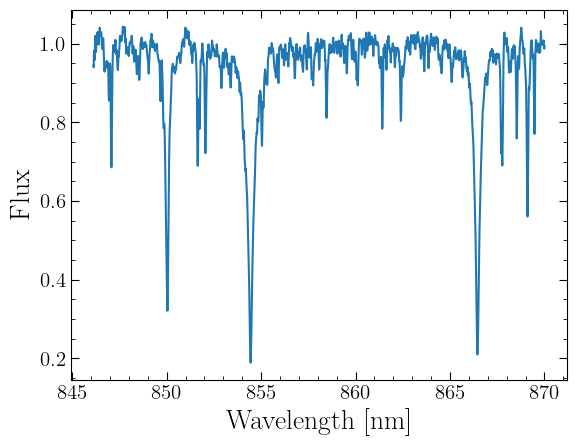

In [8]:
eg_giant = training_rvs_df.iloc[0]

plt.plot(lambdas, eg_giant['flux'])
plt.xlabel('Wavelength [nm]', fontsize=20)
plt.ylabel('Flux', fontsize=20)

In [9]:
training_rvs_df.head()

,source_id,flux,flux_error
0,458501232174305920,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -..."
1,505676671912111488,"[0.9713414, 0.97205245, 0.96980894, 0.9704494,...","[0.005380153, 0.00503135, 0.005139816, 0.00572..."
2,513104628875298176,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -..."
3,513445408752620928,"[--, --, --, --, --, --, --, --, --, --, 0.963...","[--, --, --, --, --, --, --, --, --, --, 0.033..."
4,515604123736656000,"[0.96674216, 0.96871907, 0.9699684, 0.9732878,...","[0.007674468, 0.008523305, 0.009207881, 0.0089..."


Merge `training_set` with `training_rvs_df` to have everything in the same dataframe.

In [10]:
training_set = training_set.merge(training_rvs_df, on='source_id', how='inner')

Next, we need to divide the training set into dwarfs and giants, and choose labels for each.

In [11]:
# For giants and dwarfs
# We also include total metallicity and total alpha abundances
most_reliable_giants = ['c_h', 'n_h', 'o_h', 'mg_h', 'al_h', 'si_h', 'mn_h', 'fe_h', 'ni_h', 'm_h_atm', 'alpha_m_atm']
reliable_giants = ['na_h', 'k_h', 'ca_h', 'co_h', 'ce_h']
most_reliable_dwarfs = ['c_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'm_h_atm', 'alpha_m_atm']
reliable_dwarfs = ['o_h', 'al_h', 'k_h', 'ca_h', 'mn_h']

gaia_elements = ['n_h', 'mg_h', 'si_h', 's_h', 'ca_h', 'ti_h', 'cr_h', 'fe_h', 'ni_h', 'ce_h', 'nd_h', 'm_h_atm', 'alpha_m_atm']

giant_elements = [] #most_reliable + reliable
dwarf_elements = [] #most_reliable + reliable

print("*** Gaia elements in most reliable + reliable giants: ***")
for i in range(len(most_reliable_giants)):
    if most_reliable_giants[i] in gaia_elements:
        giant_elements.append(most_reliable_giants[i])

for i in range(len(reliable_giants)):
    if reliable_giants[i] in gaia_elements:
        giant_elements.append(reliable_giants[i])

print(giant_elements)

print("*** Gaia elements in most reliable + reliable dwarfs: ***")
for i in range(len(most_reliable_dwarfs)):
    if most_reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(most_reliable_dwarfs[i])

for i in range(len(reliable_dwarfs)):
    if reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(reliable_dwarfs[i])
    
print(dwarf_elements)

*** Gaia elements in most reliable + reliable giants: ***
['n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'm_h_atm', 'alpha_m_atm', 'ca_h', 'ce_h']
*** Gaia elements in most reliable + reliable dwarfs: ***
['mg_h', 'si_h', 'fe_h', 'ni_h', 'm_h_atm', 'alpha_m_atm', 'ca_h']


Make cuts to find giants, and save everything clean and ready to use for Lux.

1. Select logg between 1.5 and 3.5

2. Select teff < 6500 (get rid of very hot ones) but no temperature cut needed for cool stars 

3. Select ones with low errors on metallicities in all elements used for giants

In [12]:
giants_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
giants_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]

training_giants = training_set[(training_set['logg'] > 1.5) & (training_set['logg'] < 3.5)]
training_giants = training_giants[(training_giants['teff'] < 6500)]

training_giants = training_giants[training_giants['e_fe_h'] < 0.1]
training_giants = training_giants[training_giants['e_mg_h'] < 0.1]
training_giants = training_giants[training_giants['e_si_h'] < 0.1]
training_giants = training_giants[training_giants['e_ni_h'] < 0.1]
training_giants = training_giants[training_giants['e_ca_h'] < 0.1]
training_giants = training_giants[training_giants['e_ce_h'] < 0.1]

print("number of giants left in the training set = ", len(training_giants))

number of giants left in the training set =  6092


Make it ready to use for Lux and save in a pkl file.

In [13]:
for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = training_giants[p].isna() | training_giants[p].astype(str).isin(['--', 'masked', '<Masked>']) | training_giants[err_col].isna() | training_giants[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = training_giants[~mask]
    med = np.median(stars_masked[p])
    training_giants.loc[mask, p] = med
    training_giants.loc[mask, err_col] = 9999

training_giants.to_pickle('data/training_set_giants.pkl')

Now the same thing for dwarfs:

1. Select logg > 3.5

2. Select teff < 6500 (get rid of very hot ones) and also get rid of cool ones (teff > 4500)

3. Select ones with low errors on metallicities in all elements used for dwarfs


In [14]:
dwarfs_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
dwarfs_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]

training_dwarfs = training_set[(training_set['logg'] > 3.5)]
training_dwarfs = training_dwarfs[(training_dwarfs['teff'] < 6500) & (training_dwarfs['teff'] > 4500)]

training_dwarfs = training_dwarfs[training_dwarfs['e_fe_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_mg_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_si_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_ni_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_ca_h'] < 0.1]

print("number of dwarfs left in the training set = ", len(training_dwarfs))

number of dwarfs left in the training set =  2392


In [15]:
for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'm_h_atm', 'alpha_m_atm']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = training_dwarfs[p].isna() | training_dwarfs[p].astype(str).isin(['--', 'masked', '<Masked>']) | training_dwarfs[err_col].isna() | training_dwarfs[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = training_dwarfs[~mask]
    med = np.median(stars_masked[p])
    training_dwarfs.loc[mask, p] = med
    training_dwarfs.loc[mask, err_col] = 9999

training_dwarfs.to_pickle('data/training_set_dwarfs.pkl')

# 2. Find target data

1. Apply KDtarget to only include stars in the target data who are represented well by the training set

2. Save IDs of those stars (target data)

3. Get RVS spectra for target data

4. Tidy up the data to be ready to use with Lux

As a reminder, `gaia_df` is the dataframe that has Gaia IDs and colors for all stars with RVS spectra with SNR > 100.

`training_giants` is the training set for giants and `training_dwarfs` is the training set for dwarfs.

In the end, we want to have a dataframe called `target_giants` and `target_dwarfs`. Target data doesn't need to have labels. 

To find the target data, we match the color magnitude diagrams of the target data and the training set, and exclude stars that are not represented in the training set.

# Plot the color magnitude diagram

We need to convert g_mean_mag to absolute magnitude:

abs_mag = phot_g_mean_mag+5 + log10(parallax/100)

In [16]:
def get_M(m, parallax):
    M = m - 5 * np.log10(1000/parallax) + 5
    return M

gaia_df['M'] = get_M(m = gaia_df['phot_g_mean_mag'], parallax=gaia_df['parallax'])
gaia_df['g-rp'] = gaia_df['phot_g_mean_mag'] - gaia_df['phot_rp_mean_mag']

training_giants['M'] = get_M(m=training_giants['phot_g_mean_mag'], parallax=training_giants['parallax'])
training_giants['g-rp'] = training_giants['phot_g_mean_mag'] - training_giants['phot_rp_mean_mag']

training_dwarfs['M'] = get_M(m=training_dwarfs['phot_g_mean_mag'], parallax=training_dwarfs['parallax'])
training_dwarfs['g-rp'] = training_dwarfs['phot_g_mean_mag'] - training_dwarfs['phot_rp_mean_mag']

/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


We can divide all gaia stars in `gaia_df` into giants and dwarfs as well.

In [17]:
giants_gaia_all = gaia_df[(gaia_df['logg_gspphot'] < 3.5) & (gaia_df['logg_gspphot'] > 1.5)]
dwarfs_gaia_all = gaia_df[(gaia_df['logg_gspphot'] > 3.5)]

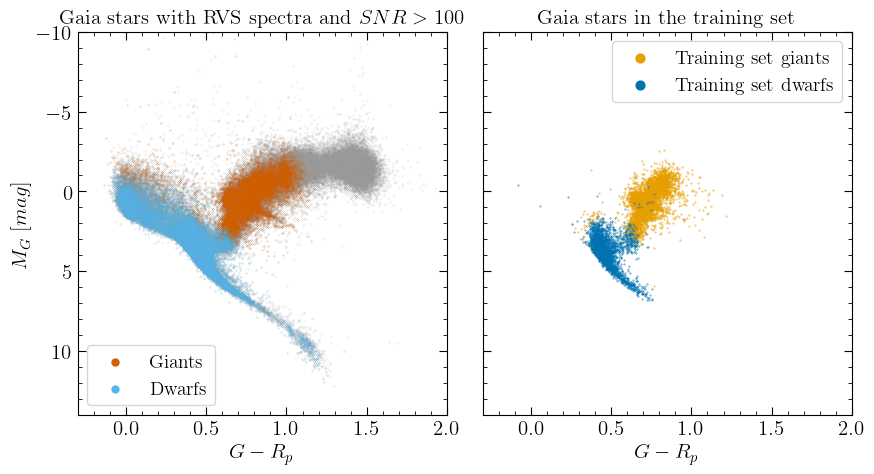

In [18]:
# Okabe-Ito colorblind-friendly palette hex codes
color_bg = '#999999'            # Grey
color_giants_all = '#D55E00'    # Vermilion
color_dwarfs_all = '#56B4E9'    # Sky Blue
color_giants_train = '#E69F00'  # Orange 
color_dwarfs_train = '#0072B2'  # Dark Blue

# Use sharey=True to link the y-axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

# Left Plot
ax1.set_title(r"Gaia stars with RVS spectra and $SNR > 100$")
ax1.scatter(gaia_df['g-rp'], gaia_df['M'], s=0.01, color=color_bg)
ax1.scatter(giants_gaia_all['g-rp'], giants_gaia_all['M'], s=0.01, label='Giants', color=color_giants_all)
ax1.scatter(dwarfs_gaia_all['g-rp'], dwarfs_gaia_all['M'], s=0.01, label='Dwarfs', color=color_dwarfs_all)
ax1.legend(markerscale=50)
ax1.set_xlabel(r"$G - R_{p}$")
ax1.set_ylabel(r"$M_{G} \ [mag]$") # Only set on the first axis
ax1.set_ylim(-10, 14)
ax1.set_xlim(-0.3, 2)
ax1.invert_yaxis() # Inverting ax1 automatically inverts ax2

# Right Plot
ax2.set_title("Gaia stars in the training set")
ax2.scatter(training_giants['g-rp'], training_giants['M'], s=0.1, label='Training set giants', color=color_giants_train)
ax2.scatter(training_dwarfs['g-rp'], training_dwarfs['M'], s=0.1, label='Training set dwarfs', color=color_dwarfs_train)
ax2.legend(markerscale=20)
ax2.set_xlabel(r"$G - R_{p}$")
ax2.set_xlim(-0.3, 2)

plt.tight_layout()
#plt.savefig('plots/hr_diagram_training.pdf', format='pdf', bbox_inches='tight', dpi=300)

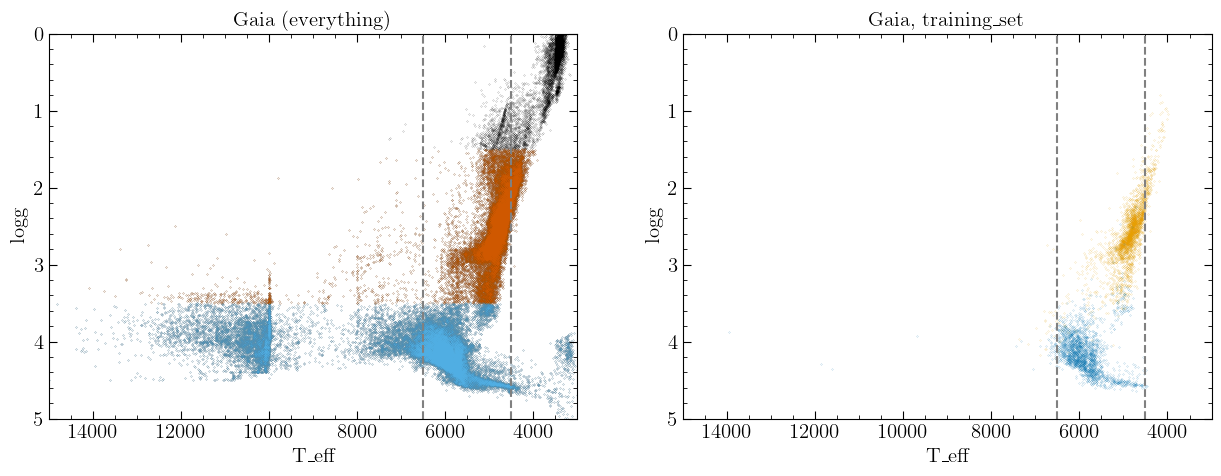

In [27]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Gaia (everything)")
plt.scatter(gaia_df['teff_gspphot'], gaia_df['logg_gspphot'], s = 0.01, color = 'black', label = 'all gaia SNR > 100')
plt.scatter(giants_gaia_all['teff_gspphot'], giants_gaia_all['logg_gspphot'], s = 0.01,
            color = color_giants_all, label = 'all gaia giants')
plt.scatter(dwarfs_gaia_all['teff_gspphot'], dwarfs_gaia_all['logg_gspphot'], s = 0.01,
            color = color_dwarfs_all, label = 'all gaia dwarfs')
plt.xlim(3000,15000)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.title("Gaia, training_set")
plt.scatter(training_giants['teff_gspphot'], training_giants['logg_gspphot'], s = 0.01, color = color_giants_train)
plt.scatter(training_dwarfs['teff_gspphot'], training_dwarfs['logg_gspphot'], s = 0.01, color = color_dwarfs_train)
plt.xlim(3000,15000)
plt.ylim(0,5)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [28]:
print("number of giants in all gaia before KDTest = ", len(giants_gaia_all))
print("number of dwarfs in all gaia before KDTest = ", len(dwarfs_gaia_all))

number of giants in all gaia before KDTest =  27004
number of dwarfs in all gaia before KDTest =  25905


Now we do the KDtarget to only keep stars in the target data who are represented with the training set. 

Disclaimer: I used AI to do this. We might need to double check!

First for giants:

In [29]:
# Giants

from scipy.spatial import cKDTree

# 1. Isolate the numeric columns (ignores the array columns like 'flux')
num_cols = training_giants.select_dtypes(include='number').columns

# 2. Replace infinities only in those columns, then drop the NaNs
training_giants_clean = training_giants.copy()
training_giants_clean[num_cols] = training_giants_clean[num_cols].replace([np.inf, -np.inf], np.nan)
training_giants_clean = training_giants_clean.dropna(subset=['M', 'g-rp'])

target_clean_g = giants_gaia_all.replace([np.inf, -np.inf], np.nan).dropna(subset=['M', 'g-rp'])

# 3. Extract and stack your 2D parameters from the clean data
train_data_giants = np.column_stack((training_giants_clean['M'], training_giants_clean['g-rp']))
target_data_giants = np.column_stack((target_clean_g['M'], target_clean_g['g-rp']))

# 4. Build the KDTree and query
tree = cKDTree(train_data_giants)
distances, _ = tree.query(target_data_giants)

# 5. Filter the target 
threshold = 0.01 
valid_mask = distances < threshold

# Apply mask directly to the cleaned DataFrame to keep all original columns
KDtarget_giants = target_clean_g[valid_mask]

In [30]:
# Dwarfs

# 1. Isolate the numeric columns (ignores the array columns like 'flux')
num_cols = training_dwarfs.select_dtypes(include='number').columns

# 2. Replace infinities only in those columns, then drop the NaNs
training_dwarfs_clean = training_dwarfs.copy()
training_dwarfs_clean[num_cols] = training_dwarfs_clean[num_cols].replace([np.inf, -np.inf], np.nan)
training_dwarfs_clean = training_dwarfs_clean.dropna(subset=['M', 'g-rp'])

target_clean_d = dwarfs_gaia_all.replace([np.inf, -np.inf], np.nan).dropna(subset=['M', 'g-rp'])

# 3. Extract and stack your 2D parameters from the clean data
train_data_dwarfs = np.column_stack((training_dwarfs_clean['M'], training_dwarfs_clean['g-rp']))
target_data_dwarfs = np.column_stack((target_clean_d['M'], target_clean_d['g-rp']))

# 4. Build the KDTree and query
tree = cKDTree(train_data_dwarfs)
distances, _ = tree.query(target_data_dwarfs)

# 5. Filter the target data
threshold = 0.01 
valid_mask = distances < threshold

# Apply mask directly to the cleaned DataFrame to keep all original columns
KDtarget_dwarfs = target_clean_d[valid_mask]

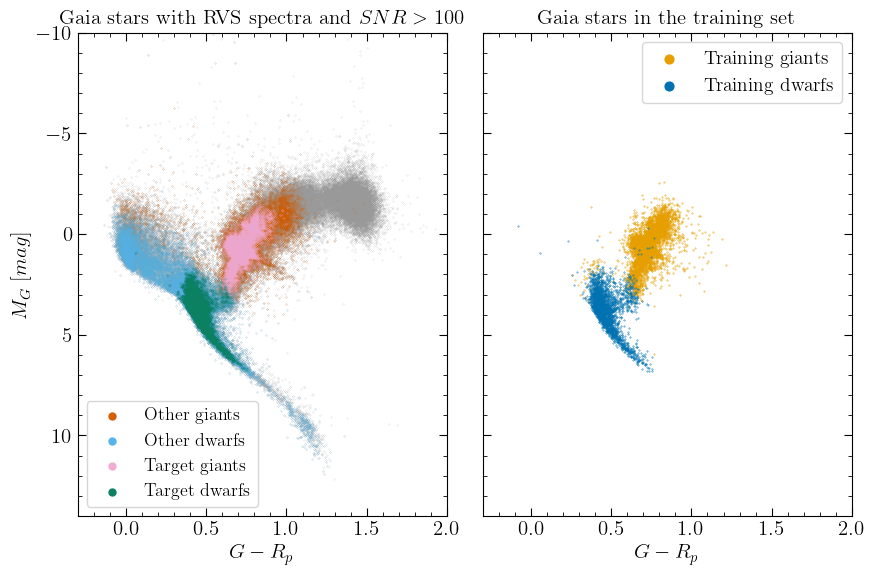

In [31]:
# Okabe-Ito colorblind-friendly palette hex codes
color_bg = '#999999'             # Grey
color_giants_all = '#D55E00'     # Vermilion
color_dwarfs_all = '#56B4E9'     # Sky Blue
color_giants_train = '#E69F00'   # Orange 
color_dwarfs_train = '#0072B2'   # Dark Blue
color_KDTest_giants = "#F2ACD3"  # Reddish Purple (Pink)
color_KDTest_dwarfs = "#0C8162"  # Bluish Green

# Use sharey=True to link the y-axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6), sharey=True)

# Left Plot
ax1.set_title(r"Gaia stars with RVS spectra and $SNR > 100$")
ax1.scatter(gaia_df['g-rp'], gaia_df['M'], s=0.01, color=color_bg)
ax1.scatter(giants_gaia_all['g-rp'], giants_gaia_all['M'], s=0.01, label='Other giants', color=color_giants_all, rasterized=True)
ax1.scatter(dwarfs_gaia_all['g-rp'], dwarfs_gaia_all['M'], s=0.01, label='Other dwarfs', color=color_dwarfs_all, rasterized=True)
ax1.scatter(KDtarget_giants['g-rp'], KDtarget_giants['M'], s=0.01, label='Target giants', color=color_KDTest_giants, rasterized=True)
ax1.scatter(KDtarget_dwarfs['g-rp'], KDtarget_dwarfs['M'], s=0.01, label='Target dwarfs', color=color_KDTest_dwarfs, rasterized=True)
ax1.legend(markerscale=50, fontsize = 13)
ax1.set_xlabel(r"$G - R_{p}$")
ax1.set_ylabel(r"$M_{G} \ [mag]$") # Only set on the first axis
ax1.set_ylim(-10, 14)
ax1.set_xlim(-0.3, 2)
ax1.invert_yaxis() # Inverting ax1 automatically inverts ax2

# Right Plot
ax2.set_title("Gaia stars in the training set")
ax2.scatter(training_giants['g-rp'], training_giants['M'], s=0.1, label='Training giants', color=color_giants_train, rasterized=True)
ax2.scatter(training_dwarfs['g-rp'], training_dwarfs['M'], s=0.1, label='Training dwarfs', color=color_dwarfs_train, rasterized=True)
ax2.legend(markerscale=20)
ax2.set_xlabel(r"$G - R_{p}$")
ax2.set_xlim(-0.3, 2)

plt.tight_layout()
plt.savefig('plots/hr_diagram_target.pdf', format='pdf', bbox_inches='tight', dpi=300)

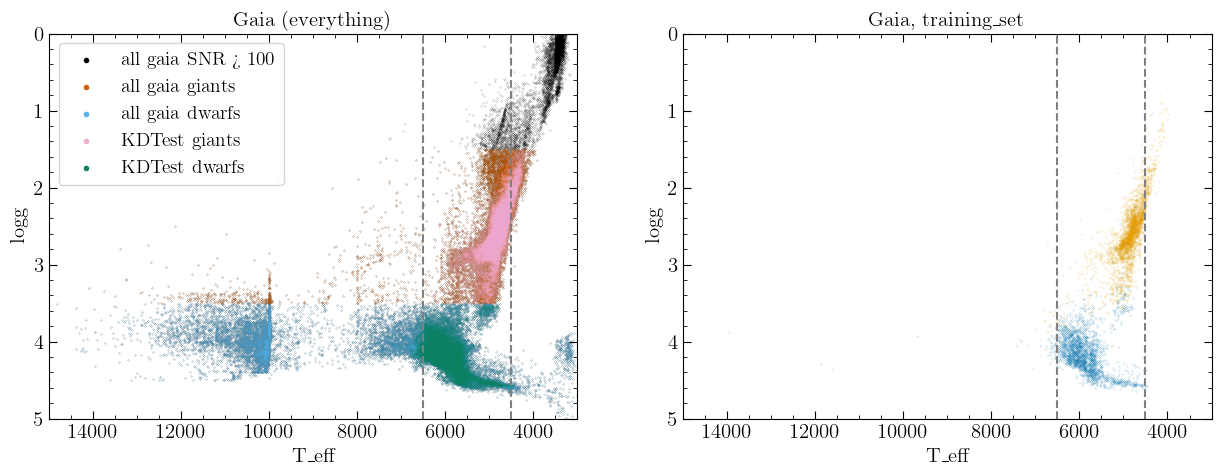

In [34]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Gaia (everything)")
plt.scatter(gaia_df['teff_gspphot'], gaia_df['logg_gspphot'], s = 0.01, color = 'black', label = 'all gaia SNR > 100')
plt.scatter(giants_gaia_all['teff_gspphot'], giants_gaia_all['logg_gspphot'], s = 0.01,
            color = color_giants_all, label = 'all gaia giants')
plt.scatter(dwarfs_gaia_all['teff_gspphot'], dwarfs_gaia_all['logg_gspphot'], s = 0.01,
            color = color_dwarfs_all, label = 'all gaia dwarfs')

plt.scatter(KDtarget_giants['teff_gspphot'], KDtarget_giants['logg_gspphot'], s = 0.01,
            color = color_KDTest_giants, label = 'KDTest giants')
plt.scatter(KDtarget_dwarfs['teff_gspphot'], KDtarget_dwarfs['logg_gspphot'], s = 0.01,
            color = color_KDTest_dwarfs, label = 'KDTest dwarfs')
plt.legend(markerscale=30)

plt.xlim(3000,15000)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.title("Gaia, training_set")
plt.scatter(training_giants['teff_gspphot'], training_giants['logg_gspphot'], s = 0.01, color = color_giants_train)
plt.scatter(training_dwarfs['teff_gspphot'], training_dwarfs['logg_gspphot'], s = 0.01, color = color_dwarfs_train)
plt.xlim(3000,15000)
plt.ylim(0,5)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [35]:
KDtarget_giants.to_csv("data/gaia_giants_filtered_KDTree.csv", index=False)
KDtarget_dwarfs.to_csv("data/gaia_dwarfs_filtered_KDTree.csv", index=False)

In [54]:
# --- Check Giants ---
# Create a mask for training stars whose source_id is NOT in the KDtarget dataframe
missing_giants_mask = ~training_giants_clean['source_id'].isin(KDtarget_giants['source_id'])

# Apply the mask to isolate the missing stars
missing_giants_df = training_giants_clean[missing_giants_mask]
print(f"Number of training giants missing from target: {len(missing_giants_df)}")

# --- Check Dwarfs ---
# Create a mask for training stars whose source_id is NOT in the KDtarget dataframe
missing_dwarfs_mask = ~training_dwarfs_clean['source_id'].isin(KDtarget_dwarfs['source_id'])

# Apply the mask to isolate the missing stars
missing_dwarfs_df = training_dwarfs_clean[missing_dwarfs_mask]
print(f"Number of training dwarfs missing from target: {len(missing_dwarfs_df)}")

Number of training giants missing from target: 3305
Number of training dwarfs missing from target: 267


Save the target  IDs to submit the query on Gaia AIP.

In [36]:
print("Number of target  giants after KDTest = ", len(KDtarget_giants))
print("Number of target  dwarfs after KDTest = ", len(KDtarget_dwarfs))

Number of target  giants after KDTest =  19627
Number of target  dwarfs after KDTest =  12472


In [37]:
# Convert the DataFrames to Astropy Tables (keeping the SOURCE_ID column name)
giants_table = Table.from_pandas(KDtarget_giants[['source_id']])
dwarfs_table = Table.from_pandas(KDtarget_dwarfs[['source_id']])

# Save them as VOTable files
giants_table.write("data/KDTree_filtered_giants_IDs.vot", format="votable", overwrite=True)
dwarfs_table.write("data/KDTree_filtered_dwarfs_IDs.vot", format="votable", overwrite=True)

Now we submit a query to get the RVS for target  giants and target dwarfs.

Replace "KDTree_giants_2" with the name of the VOT table you upload at Gaia AIP.

```sql
SELECT rvs.*

FROM "gaiadr3"."rvs_mean_spectrum" AS rvs

JOIN "gaia_user_htajer"."KDTree_filtered_giants_IDs" AS mytargets ON mytargets."source_id" = rvs.source_id

Make them ready to use for Lux and save them in a pkl file.

In [38]:
lambdas = np.linspace(846, 870, 2401)

t_giants_target = Table.read("data/target_giants_RVS.xml", format="votable")
t_dwarfs_target = Table.read("data/target_dwarfs_RVS.xml", format="votable")

target_rvs_giants = t_giants_target.to_pandas()
target_rvs_dwarfs = t_dwarfs_target.to_pandas()

Text(0, 0.5, 'Flux')

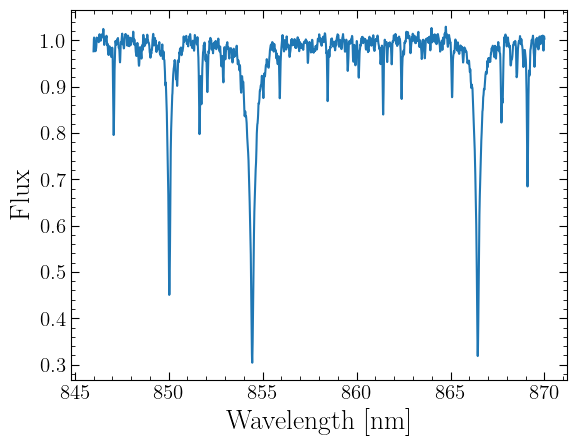

In [39]:
eg_giant = target_rvs_giants.iloc[0]

plt.plot(lambdas, eg_giant['flux'])
plt.xlabel('Wavelength [nm]', fontsize=20)
plt.ylabel('Flux', fontsize=20)

In [48]:
target_rvs_giants_flux = target_rvs_giants[['datalinkID', 'flux', 'flux_error']].copy()
target_rvs_giants_flux['source_id'] = target_rvs_giants_flux['datalinkID']
target_rvs_giants_flux.head()

target_rvs_dwarfs_flux = target_rvs_dwarfs[['datalinkID', 'flux', 'flux_error']].copy()
target_rvs_dwarfs_flux['source_id'] = target_rvs_dwarfs_flux['datalinkID']
target_rvs_dwarfs_flux.head()

,datalinkID,flux,flux_error,source_id
0,514005609922766336,"[0.9890444, 0.98159564, 0.9802874, 0.98064333,...","[0.007106618, 0.0066702426, 0.006986153, 0.007...",514005609922766336
1,464474363446935808,"[--, --, --, --, --, --, --, 0.95677775, 0.994...","[--, --, --, --, --, --, --, 0.06557224, 0.026...",464474363446935808
2,464554696516584960,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -...",464554696516584960
3,464654614636219392,"[--, --, --, --, --, --, --, 0.9982544, 0.9937...","[--, --, --, --, --, --, --, 0.005395444, 0.00...",464654614636219392
4,464862765927212416,"[--, --, --, --, --, --, --, --, --, 0.9756777...","[--, --, --, --, --, --, --, --, --, 0.0087709...",464862765927212416


In [49]:
#target_rvs_giants_flux.to_pickle('data/target_set_KDTree_giants_rvs_fluxes.pkl')
#target_rvs_dwarfs_flux.to_pickle('data/target_set_KDTree_dwarfs_rvs_fluxes.pkl')

In [50]:
gaia_df.head()

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,rvs_spec_sig_to_noise,teff_gspphot,logg_gspphot,mh_gspphot,phot_g_mean_mag,phot_rp_mean_mag,phot_bp_mean_mag,M,g-rp
0,1158184012071254400,224.580705,4.759718,NaN,NaN,NaN,19.736637,128.47984,NaN,NaN,NaN,9.909913,9.081639,10.632524,NaN,0.828274
1,458111077340747776,39.056693,57.728070,2.801820,8.709150,-3.880525,-5.394361,196.07227,NaN,NaN,NaN,8.862565,8.760913,8.895749,1.099767,0.101652
2,458111798895251072,39.148392,57.720606,2.804736,8.891490,-3.863349,-0.544152,242.61273,NaN,NaN,NaN,8.447208,8.353966,8.475003,0.686668,0.093242
3,458182957914380032,38.653083,58.189299,0.605749,3.157653,-1.858103,-18.019020,172.87813,NaN,NaN,NaN,10.574236,9.153232,13.172504,-0.514300,1.421004
4,458388188632487040,35.849756,56.854216,1.462591,1.811199,-5.075412,-8.475615,218.92624,NaN,NaN,NaN,8.528695,8.353546,8.600220,-0.645691,0.175149


In [51]:
target_rvs_dwarfs_flux

,datalinkID,flux,flux_error,source_id
0,514005609922766336,"[0.9890444, 0.98159564, 0.9802874, 0.98064333,...","[0.007106618, 0.0066702426, 0.006986153, 0.007...",514005609922766336
1,464474363446935808,"[--, --, --, --, --, --, --, 0.95677775, 0.994...","[--, --, --, --, --, --, --, 0.06557224, 0.026...",464474363446935808
2,464554696516584960,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -...",464554696516584960
3,464654614636219392,"[--, --, --, --, --, --, --, 0.9982544, 0.9937...","[--, --, --, --, --, --, --, 0.005395444, 0.00...",464654614636219392
4,464862765927212416,"[--, --, --, --, --, --, --, --, --, 0.9756777...","[--, --, --, --, --, --, --, --, --, 0.0087709...",464862765927212416
...,...,...,...,...
12467,305498004403384576,"[--, --, --, --, --, --, 0.99287623, 1.0037562...","[--, --, --, --, --, --, 0.010073728, 0.011522...",305498004403384576
12468,315874336152786944,"[0.9911038, 0.9916885, 0.9856616, 0.9794335, 0...","[0.01340191, 0.011109837, 0.009819164, 0.00940...",315874336152786944
12469,361811931961363072,"[0.99461746, 0.9890078, 0.9915004, 0.9943289, ...","[0.008420694, 0.008893601, 0.008917664, 0.0088...",361811931961363072
12470,446134818728619904,"[0.95805985, 0.97499776, 0.9788511, 0.9784692,...","[0.016172627, 0.012441538, 0.011148058, 0.0094...",446134818728619904


In [52]:
# 1. Ensure all source_id columns are integers so they match perfectly
gaia_df['source_id'] = gaia_df['source_id'].astype(int)
target_rvs_giants_flux['source_id'] = target_rvs_giants_flux['source_id'].astype(int)
target_rvs_dwarfs_flux['source_id'] = target_rvs_dwarfs_flux['source_id'].astype(int)

# 2. Extract only the source_id and the SNR column
gaia_snr_subset = gaia_df[['source_id', 'rvs_spec_sig_to_noise']]

# 3. Merge into the giants dataframe
target_rvs_giants_flux = target_rvs_giants_flux.merge(
    gaia_snr_subset, 
    on='source_id', 
    how='left'
)

# 4. Merge into the dwarfs dataframe
target_rvs_dwarfs_flux = target_rvs_dwarfs_flux.merge(
    gaia_snr_subset, 
    on='source_id', 
    how='left'
)

In [ ]:
#target_rvs_giants_flux.to_pickle('data/target_set_KDTree_giants_rvs_fluxes.pkl')
#target_rvs_dwarfs_flux.to_pickle('data/target_set_KDTree_dwarfs_rvs_fluxes.pkl')

,datalinkID,flux,flux_error,source_id,rvs_spec_sig_to_noise
0,514005609922766336,"[0.9890444, 0.98159564, 0.9802874, 0.98064333,...","[0.007106618, 0.0066702426, 0.006986153, 0.007...",514005609922766336,137.47653
1,464474363446935808,"[--, --, --, --, --, --, --, 0.95677775, 0.994...","[--, --, --, --, --, --, --, 0.06557224, 0.026...",464474363446935808,136.02110
2,464554696516584960,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -...",464554696516584960,186.33401
3,464654614636219392,"[--, --, --, --, --, --, --, 0.9982544, 0.9937...","[--, --, --, --, --, --, --, 0.005395444, 0.00...",464654614636219392,291.84543
4,464862765927212416,"[--, --, --, --, --, --, --, --, --, 0.9756777...","[--, --, --, --, --, --, --, --, --, 0.0087709...",464862765927212416,149.21707
